In [4]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [5]:
# Загружаем датасет Dota 2 heroes

df = pd.read_csv('/content/dota2HeroPick.csv', index_col=0)

# Кодируем Primary Attribute как числовую целевую метку
df['Primary Attribute Code'] = df['Primary Attribute'].map({'all': 0, 'str': 1, 'agi': 2, 'int': 3})

df.head()

,Name,Primary Attribute,Attack Type,Attack Range,Roles,Total Pro wins,Times Picked,Times Banned,Win Rate,Niche Hero?,Primary Attribute Code
0,Abaddon,all,Melee,150,"Support, Carry, Durable",8,24,61,33.33,False,0
1,Alchemist,str,Melee,150,"Carry, Support, Durable, Disabler, Initiator, ...",23,55,22,41.82,False,1
2,Ancient Apparition,int,Ranged,675,"Support, Disabler, Nuker",40,77,73,51.95,False,3
3,Anti-Mage,agi,Melee,150,"Carry, Escape, Nuker",40,66,78,60.61,False,2
4,Arc Warden,agi,Ranged,625,"Carry, Escape, Nuker",5,14,31,35.71,False,2


In [6]:
vals = df['Primary Attribute'].unique()
vals

array(['all', 'str', 'int', 'agi'], dtype=object)

In [7]:
# Оставляем только числовые признаки для кластеризации.
# Attack Type кодируем в числовой. Primary Attribute (целевая) убираем из признаков.

df['Attack Type Enc'] = df['Attack Type'].map({'Melee': 0, 'Ranged': 1})
df['Niche Hero Enc'] = df['Niche Hero?'].astype(int)

cols_for_clusters = ['Attack Range', 'Total Pro wins', 'Times Picked', 'Times Banned',
                     'Win Rate', 'Attack Type Enc', 'Niche Hero Enc']

data = df[cols_for_clusters].copy()

In [8]:
data.head()

,Attack Range,Total Pro wins,Times Picked,Times Banned,Win Rate,Attack Type Enc,Niche Hero Enc
0,150,8,24,61,33.33,0,0
1,150,23,55,22,41.82,0,0
2,675,40,77,73,51.95,1,0
3,150,40,66,78,60.61,0,0
4,625,5,14,31,35.71,1,0


In [9]:
X = data
y = df['Primary Attribute Code']
yvals = df['Primary Attribute']

In [10]:
import mpl_toolkits.mplot3d  # noqa: F401
from sklearn.cluster import KMeans

Для 3D-визуализации используем три наиболее информативных признака: , ,

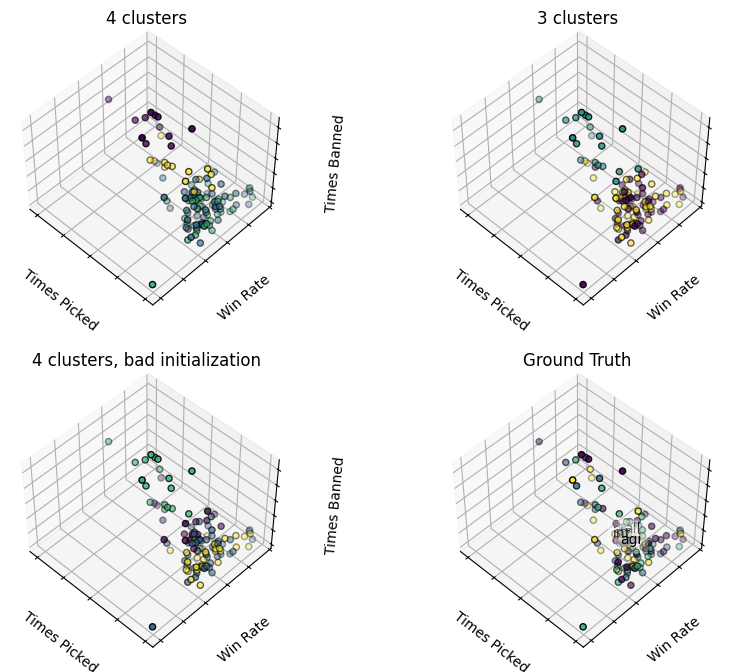

In [11]:
estimators = [
    ('k_means_4',        KMeans(n_clusters=4)),
    ('k_means_3',        KMeans(n_clusters=3)),
    ('k_means_bad_init', KMeans(n_clusters=4, n_init=1, init='random')),
]

fig = plt.figure(figsize=(10, 8))
titles = ['4 clusters', '3 clusters', '4 clusters, bad initialization']

for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection='3d', elev=48, azim=134)
    est.fit(X)
    labels = est.labels_

    ax.scatter(X['Times Picked'], X['Win Rate'], X['Times Banned'],
               c=labels.astype(float), edgecolor='k')

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel('Times Picked')
    ax.set_ylabel('Win Rate')
    ax.set_zlabel('Times Banned')
    ax.set_title(title)

# Ground truth
ax = fig.add_subplot(2, 2, 4, projection='3d', elev=48, azim=134)

for name, label in zip(vals, range(len(vals))):
    ds = df[df['Primary Attribute'] == name]
    ax.text3D(
        ds['Times Picked'].mean(),
        ds['Win Rate'].mean(),
        ds['Times Banned'].mean(),
        name,
        horizontalalignment='center',
        bbox=dict(alpha=0.2, edgecolor='w', facecolor='w'),
    )

ax.scatter(X['Times Picked'], X['Win Rate'], X['Times Banned'],
           c=y, edgecolor='k')

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel('Times Picked')
ax.set_ylabel('Win Rate')
ax.set_zlabel('Times Banned')
ax.set_title('Ground Truth')

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

In [12]:
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score

n_clusters = np.arange(2, 21)

In [13]:
best_metric = [0, 10000, 0, []]

silhouette_score_values = []
adjusted_rand_score_values = []

for n in n_clusters:
    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y, y_pred)
    adjusted_rand_score_values.append(score2)

    if score1 < best_metric[1] and score2 > best_metric[2]:
        best_metric[1] = score1
        best_metric[2] = score2
        best_metric[3] = clusterer.cluster_centers_
        best_metric[0] = n

In [14]:
best_metric

[np.int64(3),
 np.float64(0.47771035774538834),
 0.1663301943462322,
 array([[5.46886792e+02, 7.46226415e+01, 1.49943396e+02, 1.74150943e+02,
         4.91562264e+01, 1.00000000e+00, 2.07547170e-01],
        [2.89761905e+02, 2.09238095e+02, 4.10809524e+02, 7.04952381e+02,
         5.10295238e+01, 4.28571429e-01, 5.55111512e-17],
        [1.68100000e+02, 6.11200000e+01, 1.24720000e+02, 1.52000000e+02,
         4.89510000e+01, 4.00000000e-02, 1.80000000e-01]])]

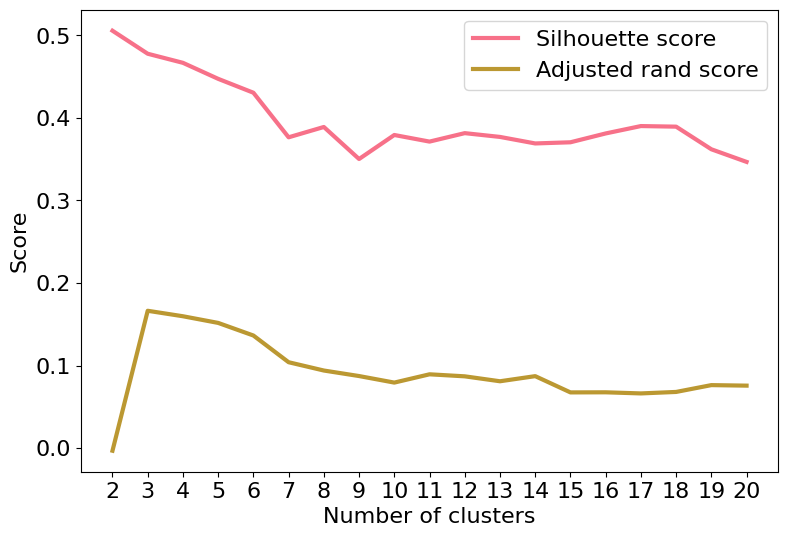

In [15]:
plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Silhouette score')
plt.plot(n_clusters, adjusted_rand_score_values, linewidth=3, label='Adjusted rand score')
plt.xlabel('Number of clusters', size=16)
plt.ylabel('Score', size=16)
plt.xticks(n_clusters, size=16)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)
plt.show()

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram

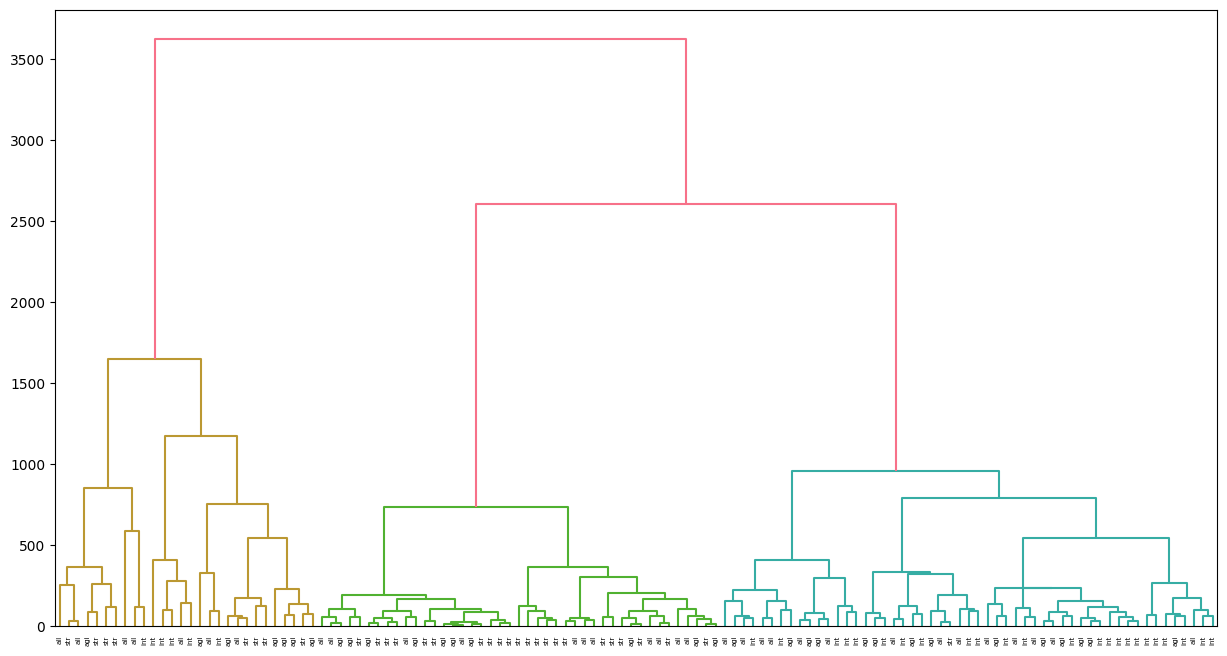

In [17]:
samples = data.values

mergings = linkage(samples, method='ward')

plt.figure(figsize=(15, 8))
dendrogram(mergings,
           labels=list(yvals),
           leaf_rotation=90,
           leaf_font_size=5,
           )
plt.show()

In [18]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [19]:
mins = X.shape[1]

['y', 'b', 'g', 'r', 'c', 'm']


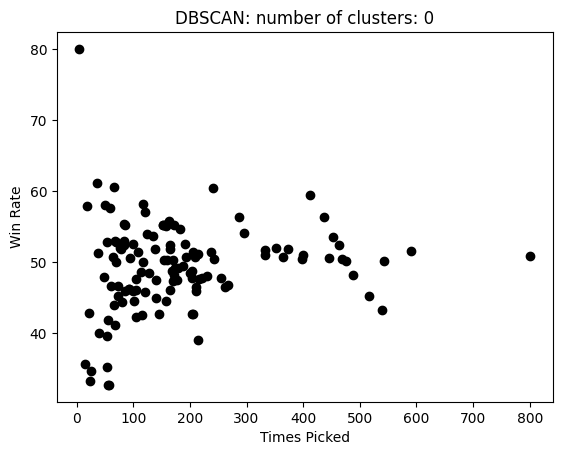

In [20]:
db = DBSCAN(eps=5, min_samples=4).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

unique_labels = set(labels)
colors = ['y', 'b', 'g', 'r', 'c', 'm']
print(colors)
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'k'

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy['Times Picked'], xy['Win Rate'], 'o', markerfacecolor=col,
             markeredgecolor='k', markersize=6)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy['Times Picked'], xy['Win Rate'], 'o', markerfacecolor=col,
             markeredgecolor='k', markersize=6)

plt.xlabel('Times Picked')
plt.ylabel('Win Rate')
plt.title('DBSCAN: number of clusters: %d' % n_clusters_)
plt.show()

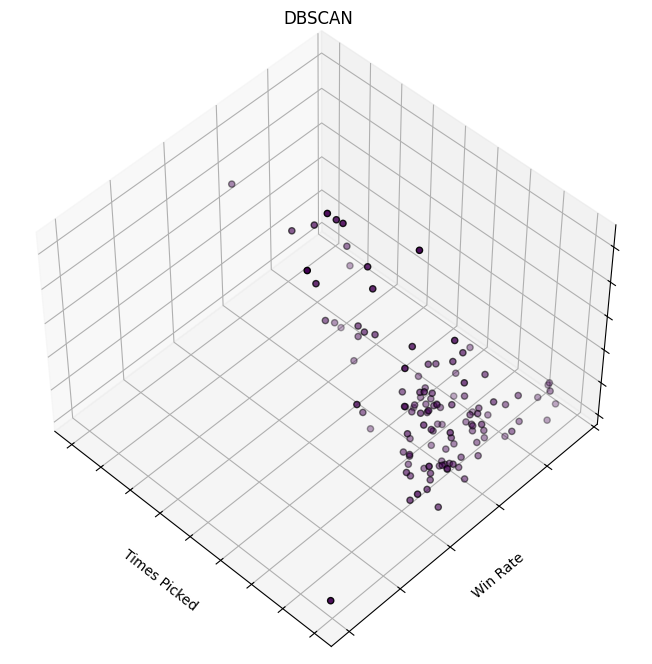

In [21]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection='3d', elev=48, azim=134)

ax.scatter(X['Times Picked'], X['Win Rate'], X['Times Banned'],
           c=labels.astype(float), edgecolor='k')

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel('Times Picked')
ax.set_ylabel('Win Rate')
ax.set_zlabel('Times Banned')
ax.set_title('DBSCAN')

plt.show()

# DBSCAN — это алгоритм для данных с произвольной геометрией кластеров и явными выбросами. Наш датасет — небольшой, равномерный, без выраженной кластерной структуры по плотности. KMeans с k=3 здесь принципиально лучше подходит, потому что просто делит пространство на компактные сферические группы, что соответствует реальной структуре данных.

In [26]:
data.head(10)

,Attack Range,Total Pro wins,Times Picked,Times Banned,Win Rate,Attack Type Enc,Niche Hero Enc
0,150,8,24,61,33.33,0,0
1,150,23,55,22,41.82,0,0
2,675,40,77,73,51.95,1,0
3,150,40,66,78,60.61,0,0
4,625,5,14,31,35.71,1,0
5,150,122,262,222,46.56,0,0
6,400,84,152,104,55.26,1,1
7,400,19,54,105,35.19,1,0
8,150,170,333,484,51.05,0,0
9,150,70,157,461,44.59,0,0


In [25]:
data.describe()

,Attack Range,Total Pro wins,Times Picked,Times Banned,Win Rate,Attack Type Enc,Niche Hero Enc
count,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000
mean,350.604839,91.975806,183.951613,255.112903,49.390726,0.516129,0.161290
std,200.271759,73.328691,143.145492,241.567349,6.317535,0.501767,0.369291
min,150.000000,4.000000,5.000000,18.000000,32.730000,0.000000,0.000000
25%,150.000000,40.750000,82.500000,80.000000,46.217500,0.000000,0.000000
50%,340.000000,79.000000,156.000000,185.500000,50.250000,1.000000,0.000000
75%,550.000000,106.000000,215.250000,325.000000,52.492500,1.000000,0.000000
max,700.000000,407.000000,801.000000,1049.000000,80.000000,1.000000,1.000000


In [29]:
labels

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1])

In [27]:
sc = metrics.silhouette_score(X, labels)
print('Silhouette Coefficient: %0.2f' % sc)
ari = adjusted_rand_score(y, labels)
print('Adjusted Rand Index: %0.2f' % ari)

ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

### Результаты K-Means кластеризации

In [24]:
print(f"Оптимальное количество кластеров (по K-Means): {best_metric[0]}")
print(f"Silhouette Score для оптимального количества кластеров: {best_metric[1]:.2f}")
print(f"Adjusted Rand Index для оптимального количества кластеров: {best_metric[2]:.2f}")


Оптимальное количество кластеров (по K-Means): 3
Silhouette Score для оптимального количества кластеров: 0.48
Adjusted Rand Index для оптимального количества кластеров: 0.17


Итог: DBSCAN использует евклидово расстояние, и признаки с большими значениями (например, Times Picked) полностью доминируют, а маленькие (Win Rate) практически не влияют на расстояние. Без нормализации DBSCAN с фиксированным eps просто не может выделить разумные кластеры. Большинство точек попадают в шум(-1)